In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

In [2]:
liver_disorders = fetch_ucirepo(id = 60)

In [3]:
# Data in pandas dataframe
X = liver_disorders.data.features
Y = liver_disorders.data.targets

In [4]:
# Standard Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Define range of regularization parameter values
lambdas = np.logspace(2,4,100)

In [6]:
# Fit ridge and lasso models to different alpha values
coefs_ridge = []

for alpha in lambdas:
    ridge = Ridge(alpha = alpha, fit_intercept = False)
    ridge.fit(X_scaled, Y)
    coefs_ridge.append(ridge.coef_)

In [7]:
# Reshape the 3D array

n_features = X.shape[1]
coefs_ridge_flat = np.array(coefs_ridge).reshape(-1, n_features)

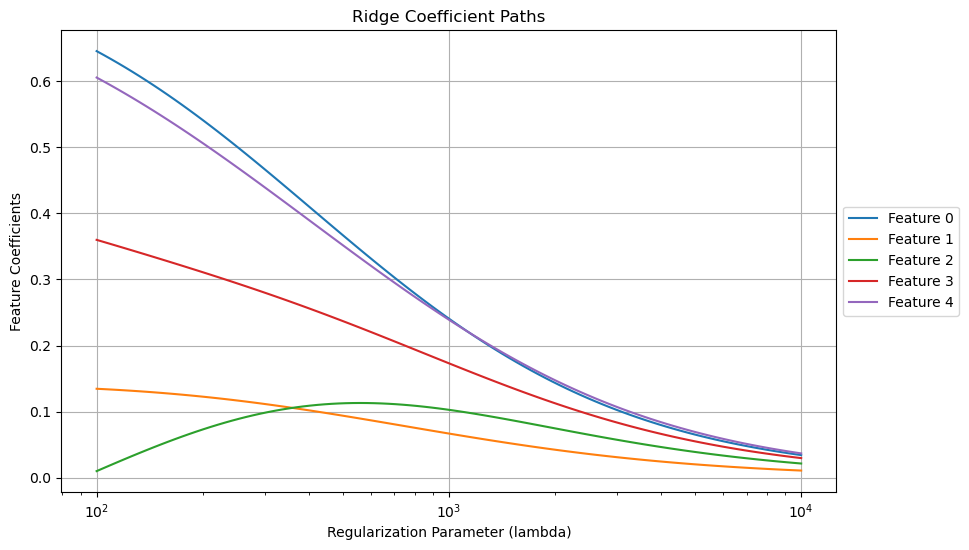

In [10]:
# Plot coefficient paths for Ridge
plt.figure(figsize = (10,6))
for i in range(n_features):
    plt.plot(lambdas,coefs_ridge_flat[:, i],label = 'Feature {}'.format(i))
plt.xscale('log')
plt.xlabel('Regularization Parameter (lambda)')
plt.ylabel('Feature Coefficients')
plt.title('Ridge Coefficient Paths')
plt.legend(loc = 'center left' , bbox_to_anchor = (1,0.5))
plt.grid(True)
plt.show()